In [1]:
using Revise

using PVlib
using Dates
using Plots
using Pkg
Pkg.activate(temp=true)
Pkg.add("StatsPlots")
using StatsPlots

using CSV
using DataFrames

[ Info: Precompiling IJuliaReviseExt [b74c6c38-2542-566b-9b5f-490bff998244] (cache misses: wrong dep version loaded (10), incompatible header (8))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
  Activating new project at `C:\Users\jtgrasb\AppData\Local\Temp\jl_C2ZXYw`
    Updating registry at `C:\Users\jtgrasb\.julia\registries\General`
┌ Info: The General registry is installed via git. Consider reinstalling it via
│ the newer faster direct from tarball format by running:
│   pkg> registry rm General; registry add General
└ 
    Updating git-repo `https://github.com/JuliaRegistries/General.git`
   Resolving package versions...
   Installed HypergeometricFunctions ─ v0.3.30
   Installed Unitful ───────────────── v1.24.0
   Installed Formatting ────────────── v0.4.3
   Installed Roots ─────────────────── v3.0.6
   Installed MuladdMacro ───────────── v0.2.7
   Installed SpecialFunctions ──────── v2.8.1
   Installed StatsFuns ─────────

In [2]:
# latitude, longitude, name, altitude, timezone
coordinates = [
    (lat=32.2, lon=-111.0, name="Tucson", elevation=700, tz=TimeZone("America/Denver")),
    (lat=35.1, lon=-106.6, name="Albuquerque", elevation=1500, tz=TimeZone("America/Denver")),
    (lat=37.8, lon=-122.4, name="San Francisco", elevation=10, tz=TimeZone("America/Chicago")),
    (lat=52.5, lon=13.4, name="Berlin", elevation=34, tz=TimeZone("Europe/Berlin")),
]

4-element Vector{@NamedTuple{lat::Float64, lon::Float64, name::String, elevation::Int64, tz::TimeZones.VariableTimeZone}}:
 (lat = 32.2, lon = -111.0, name = "Tucson", elevation = 700, tz = tz"America/Denver")
 (lat = 35.1, lon = -106.6, name = "Albuquerque", elevation = 1500, tz = tz"America/Denver")
 (lat = 37.8, lon = -122.4, name = "San Francisco", elevation = 10, tz = tz"America/Chicago")
 (lat = 52.5, lon = 13.4, name = "Berlin", elevation = 34, tz = tz"Europe/Berlin")

In [3]:
module_filename = "sam-library-sandia-modules-2015-6-30.csv"
module_name = "Canadian Solar CS5P-220M [ 2009]"  # "BP Solar SX305 [2007 (E)]"

inverter_filename = "sam-library-cec-inverters-2019-03-05.csv"
inverter_name = "ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # "SMA America: SB 240-US-10 [240V]"

pv_module = read_solar_module(module_name, module_filename)
pv_inverter = read_solar_inverter(inverter_name, inverter_filename)

SolarInverter
────────────
name       │ ABB: MICRO-0.25-I-OUTD-US-208 [208V]
vac        │ 208.0
pso        │ 2.089607
paco       │ 250.0
pdco       │ 259.588593
vdco       │ 40.0
c0         │ -4.1e-5
c1         │ -9.1e-5
c2         │ 0.000494
c3         │ -0.013171
pnt        │ 0.075
vdcmax     │ 50.0
idcmax     │ 6.489715
mppt_low   │ 30.0
mppt_high  │ 50.0
cec_date   │ n/a
cec_type   │ Utility Interactive


In [4]:
for (latitude, longitude, name, elevation, tz) in coordinates
    println("City: $name, lat=$latitude, lon=$longitude, elevation=$elevation, tz=$tz")
end

City: Tucson, lat=32.2, lon=-111.0, elevation=700, tz=America/Denver
City: Albuquerque, lat=35.1, lon=-106.6, elevation=1500, tz=America/Denver
City: San Francisco, lat=37.8, lon=-122.4, elevation=10, tz=America/Chicago
City: Berlin, lat=52.5, lon=13.4, elevation=34, tz=Europe/Berlin


In [5]:
ac_power_totals = Float64[]

for (latitude, longitude, name, elevation, tz) in coordinates

    surface_tilt = latitude
    surface_azimuth = 180
    albedo = 0.25

    weather_data = get_meteorological_data_pvgis(latitude, longitude, Date(1900, 1, 1), Date(2026, 1, 1), tz, false)
    solar_position = get_solar_position(latitude, longitude, elevation, weather_data)
    total_irradiance = get_total_irradiance(surface_tilt, surface_azimuth, weather_data, solar_position, albedo) # verified same
    cell_temp = sapm_cell_temperature(total_irradiance, weather_data) # verified same
    effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, solar_position, surface_tilt, surface_azimuth, elevation) # verified same
    dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp)
    ac_power = sandia_ac_power(pv_inverter, dc_components) # verified same

    ac_power_total = sum(getfield.(ac_power,:ac_power))
    push!(ac_power_totals, ac_power_total)
end

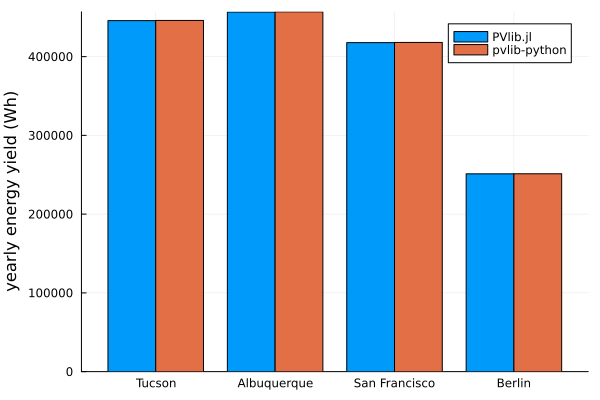

"c:\\Users\\jtgrasb\\Documents\\GitHub\\PVlib.jl\\examples\\pvlib_validation.png"

In [ ]:
py_results = CSV.read("../data/python_validation_result.csv", DataFrame)
py_energy = py_results.yearly_energy

names = getfield.(coordinates, :name)

p = groupedbar(
    names,
    [ac_power_totals py_energy],
    ylabel = "yearly energy yield (Wh)",
    label = ["PVlib.jl" "pvlib-python"],
    yformatter = y -> string(round(Int, y)),
)
display(p)

#savefig(p, "pvlib_validation.png")

In [7]:
percent_error = 100 .* abs.(ac_power_totals .- py_energy) ./ abs.(py_energy)

println("Energy yield and percentage error across locations:")
for (name, ac_total, py_total, err) in zip(names, ac_power_totals, py_energy, percent_error)
    println("$name:")
    println("  PVlib.jl AC power total: $(round(ac_total, digits=2))")
    println("  pvlib-python energy:     $(round(py_total, digits=2))")
    println("  Percentage error:        $(round(err, digits=2)) %")
end

Energy yield and percentage error across locations:
Tucson:
  PVlib.jl AC power total: 445711.4
  pvlib-python energy:     445963.76
  Percentage error:        0.06 %
Albuquerque:
  PVlib.jl AC power total: 456650.97
  pvlib-python energy:     456909.79
  Percentage error:        0.06 %
San Francisco:
  PVlib.jl AC power total: 417797.27
  pvlib-python energy:     418052.83
  Percentage error:        0.06 %
Berlin:
  PVlib.jl AC power total: 251185.83
  pvlib-python energy:     251239.47
  Percentage error:        0.02 %
